# Women's Model

This notebook makes the machine learning model. Remember to uncomment the last cell if you would like to save the model. 

### Data Setup

In [1]:
import pandas as pd

pd.set_option('display.max_columns', 100)

df_mod = pd.read_parquet(r'..\data\preprocessed\womens_model_data\model_data.parquet')

df_mod

,Season,Result,Team A ID,Team A,Team B ID,Team B,Round,Location,Seed,Head to Head,Common Opps,Past Year Tournament Result,Past 4 Years Tournament Results,WIN%,ADJOE,ADJDE,ADJEM,BARTHAG,ADJ T.,WAB,Past Year Efficiency Margin,Past 4 Years Efficiency Margin,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo,Starters,Mu,OS Rating,Team Win%,Team EFG%,Opponent EFG%,Team TOR,Team ORBR,Team FTR,Opponent FTR,Team A ADJOE Team B ADJDE,Team B ADJOE Team A ADJDE,Team A Offense Team B Defense,Team B Offense Team A Defense,Team A Efficiency Margin,Team B Efficiency Margin
0,2012,1,3116,Arkansas,3173,Dayton,1,0,-5,NaN,-0.133288,-1.0,-0.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.058519,-0.055132,-0.046267,0.030005,0.005625,-0.024380,-8.312479,-0.147109,-1.395719,-0.848218,-0.051168,-0.013769,-0.005223,-0.255442,2.440872,-1.447517,-2.717337,NaN,NaN,1.732644,1.702639,0.242118,0.212113
1,2012,1,3163,Connecticut,3341,Prairie View,1,0,-15,NaN,1.433520,4.0,2.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.599396,0.587873,5.533340,0.683283,0.335346,-0.347937,1.164885,0.949023,30.158018,30.046412,0.362659,0.114824,-0.103051,-2.108403,2.702770,-0.994398,-5.867203,NaN,NaN,2.091627,1.408344,0.612579,-0.070705
2,2012,1,3177,DePaul,3140,BYU,1,0,-3,NaN,-0.333089,3.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.116604,0.152977,0.942105,0.021541,0.069822,0.048281,2.527211,-0.004834,-3.043846,-2.413117,-0.118952,0.002505,0.059121,0.348861,-1.196064,-2.637275,-1.103772,NaN,NaN,1.830661,1.809119,0.243769,0.222228
3,2012,1,3211,Gonzaga,3353,Rutgers,1,0,5,NaN,NaN,2.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.046283,-0.025164,-0.565226,-0.048145,0.054367,0.102513,4.992007,-0.052592,3.506069,2.932589,0.129032,0.046226,0.050877,-3.790769,1.929341,-0.756823,-4.345191,NaN,NaN,1.740986,1.789131,0.216886,0.265031
4,2012,1,3243,Kansas St,3343,Princeton,1,0,-1,NaN,-0.653105,0.0,-0.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.023129,0.142977,0.166964,-0.066541,-0.049703,0.016838,-6.785140,-0.111061,-5.096065,-3.479339,-0.263393,-0.042403,0.027494,-1.713529,-5.754640,-4.428173,2.920438,NaN,NaN,1.668275,1.734816,0.203945,0.270486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,2024,-1,3425,USC,3163,Connecticut,4,0,-2,NaN,0.481418,-2.0,-4.333333,-0.009775,-6.9,3.6,-10.5,-0.0089,-1.6,0.9,-0.157742,-0.286640,-0.166886,-0.130033,-0.062637,0.067396,-2.007100,0.041140,-0.349031,-0.542839,-0.009775,-0.065520,0.024896,-0.811250,3.342643,3.696660,5.252871,190.4,200.9,1.813021,1.943054,0.373978,0.504011
1508,2024,-1,3261,LSU,3234,Iowa,4,0,2,NaN,0.228265,1.0,-0.666667,-0.030303,-9.2,-4.9,-4.3,-0.0016,-0.3,-3.6,0.033278,-0.057085,-0.519727,-0.045249,-0.100185,-0.054936,-0.004142,-0.025061,-1.030708,-0.630969,-0.030303,-0.090941,-0.041529,2.194908,7.422296,7.204079,0.376040,203.6,207.9,1.948809,1.994058,0.402188,0.447437
1509,2024,-1,3163,Connecticut,3234,Iowa,5,0,2,NaN,0.071684,-3.0,1.000000,-0.030303,-6.1,-9.4,3.3,0.0046,-4.6,-1.2,0.019989,0.140849,0.181251,0.056574,-0.058381,-0.114955,-4.357594,0.121339,0.057720,0.323102,-0.030303,-0.033640,-0.046569,0.051163,-0.383625,-3.841393,-2.045993,206.7,203.4,1.990613,1.934039,0.504011,0.447437
1510,2024,-1,3301,NC State,3376,South Carolina,5,0,2,NaN,-0.379131,-4.0,-3.000000,-0.181818,-11.4,3.1,-14.5,-0.0105,-1.9,-6.3,-0.272947,-0.153657,-2.108665,-0.186511,-0.120974,0.065538,-2.295430,-0.343475,-12.321040,-11.483347,-0.181818,-0.071161,0.044675,-0.526132,-3.686611,1.803896,-3.239472,184.3,198.8,1.736976,1.923488,0.354143,0.540655


In [2]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Season                           1512 non-null   int64  
 1   Result                           1512 non-null   int64  
 2   Team A ID                        1512 non-null   int64  
 3   Team A                           1512 non-null   object 
 4   Team B ID                        1512 non-null   int64  
 5   Team B                           1512 non-null   object 
 6   Round                            1512 non-null   int64  
 7   Location                         1512 non-null   int64  
 8   Seed                             1512 non-null   int64  
 9   Head to Head                     204 non-null    float64
 10  Common Opps                      1152 non-null   float64
 11  Past Year Tournament Result      1386 non-null   float64
 12  Past 4 Years Tournam

Get monotonic constraints

In [3]:
correlations = df_mod.corr(numeric_only=True)['Result']

correlations.round(2).sort_values()

Seed                              -0.62
Adjusted Defense                  -0.57
Team B Offense Team A Defense     -0.55
ADJDE                             -0.54
Team B ADJOE Team A ADJDE         -0.53
Team B Efficiency Margin          -0.49
Opponent FTR                      -0.29
Opponent EFG%                     -0.25
Team TOR                          -0.20
Season                             0.00
Team B ID                         -0.00
Round                              0.00
Team A ID                          0.00
Team FTR                           0.06
Team ORBR                          0.16
ADJ T.                             0.16
Adjusted Tempo                     0.17
Team EFG%                          0.37
Team Win%                          0.38
WIN%                               0.39
Common Opps                        0.40
Location                           0.48
Team A Efficiency Margin           0.49
Past 4 Years Tournament Results    0.51
BARTHAG                            0.52


In [4]:
# df_mod = df_mod.loc[:, ['Season', 'Team A ID', 'Team A', 'Team B ID', 'Team B'] + list(correlations.loc[correlations.abs() >= 0.00].index)]

# df_mod

In [5]:
correlations = df_mod.corr(numeric_only=True)['Result']

correlations.round(2).sort_values()

Seed                              -0.62
Adjusted Defense                  -0.57
Team B Offense Team A Defense     -0.55
ADJDE                             -0.54
Team B ADJOE Team A ADJDE         -0.53
Team B Efficiency Margin          -0.49
Opponent FTR                      -0.29
Opponent EFG%                     -0.25
Team TOR                          -0.20
Season                             0.00
Team B ID                         -0.00
Round                              0.00
Team A ID                          0.00
Team FTR                           0.06
Team ORBR                          0.16
ADJ T.                             0.16
Adjusted Tempo                     0.17
Team EFG%                          0.37
Team Win%                          0.38
WIN%                               0.39
Common Opps                        0.40
Location                           0.48
Team A Efficiency Margin           0.49
Past 4 Years Tournament Results    0.51
BARTHAG                            0.52


In [6]:
correlations_threshold = 0.10

correlations.loc[correlations.abs() < correlations_threshold].round(2)

Season       0.00
Team A ID    0.00
Team B ID   -0.00
Round        0.00
Team FTR     0.06
Name: Result, dtype: float64

In [7]:
monotone_constraints_dict = dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations > correlations_threshold], 
    [1 for _ in range((correlations > correlations_threshold).sum())]
))

In [8]:
monotone_constraints_dict = dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations > correlations_threshold], 
    [1 for _ in range((correlations > correlations_threshold).sum())]
))

monotone_constraints_dict.update(dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations < -correlations_threshold], 
    [-1 for _ in range((correlations < -correlations_threshold).sum())]
)))

del monotone_constraints_dict['Result']

monotone_constraints_dict

{'Location': 1,
 'Head to Head': 1,
 'Common Opps': 1,
 'Past Year Tournament Result': 1,
 'Past 4 Years Tournament Results': 1,
 'WIN%': 1,
 'ADJOE': 1,
 'ADJEM': 1,
 'BARTHAG': 1,
 'ADJ T.': 1,
 'WAB': 1,
 'Past Year Efficiency Margin': 1,
 'Past 4 Years Efficiency Margin': 1,
 'Rating': 1,
 'Efficiency Margin': 1,
 'Adjusted Offense': 1,
 'Adjusted Tempo': 1,
 'Starters': 1,
 'Mu': 1,
 'OS Rating': 1,
 'Team Win%': 1,
 'Team EFG%': 1,
 'Team ORBR': 1,
 'Team A ADJOE Team B ADJDE': 1,
 'Team A Offense Team B Defense': 1,
 'Team A Efficiency Margin': 1,
 'Seed': -1,
 'ADJDE': -1,
 'Adjusted Defense': -1,
 'Opponent EFG%': -1,
 'Team TOR': -1,
 'Opponent FTR': -1,
 'Team B ADJOE Team A ADJDE': -1,
 'Team B Offense Team A Defense': -1,
 'Team B Efficiency Margin': -1}

Create train-val-test folds

In [9]:
from sklearn.model_selection import GroupKFold
import numpy as np

np.random.seed(22)

gkf = GroupKFold(n_splits=3)

cv_data = []
for train_val_index, test_index in gkf.split(df_mod.index, groups=df_mod['Season']):
    df_train_val_iter = df_mod.loc[train_val_index, :]
    df_test_iter = df_mod.loc[test_index, :]

    val_seasons = np.random.choice(df_train_val_iter['Season'].unique(), size=3, replace=False)

    X_train_iter = (
        df_train_val_iter
        .loc[~df_train_val_iter['Season'].isin(val_seasons), :]
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )
    X_val_iter = (
        df_train_val_iter
        .loc[df_train_val_iter['Season'].isin(val_seasons), :]
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )
    X_test_iter = (
        df_test_iter
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )

    y_train_iter = (
        df_train_val_iter
        .loc[~df_train_val_iter['Season'].isin(val_seasons), 'Result']
    )
    y_val_iter = (
        df_train_val_iter
        .loc[df_train_val_iter['Season'].isin(val_seasons), 'Result']
    )
    y_test_iter = (
        df_test_iter['Result']
    )

    cv_data.append((
        X_train_iter, 
        X_val_iter, 
        X_test_iter, 
        y_train_iter, 
        y_val_iter, 
        y_test_iter,
        df_test_iter,
    ))

len(cv_data)

3

In [10]:
monotone_constraints = [monotone_constraints_dict.get(c, 0) for c in X_train_iter.columns]

monotone_constraints

[0,
 1,
 -1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 -1,
 1,
 0,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 -1]

### Hyperparameter Tuning

In [11]:
from sklearn.metrics import brier_score_loss  # log_loss
from lightgbm import LGBMClassifier
import optuna
import numpy as np

testing_data = []
def objective(trial, cv_data=cv_data):
    # model tuning
    params = {
        'random_state': 22,
        # 'metric': 'binary_logloss',
        'metric': 'rmse',  # brier score
        'verbosity': -1,
        'n_estimators': 500,
        'early_stopping_round': 25,
        'monotone_constraints': monotone_constraints,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0),
        'max_depth': trial.suggest_int('max_depth', 1, 32),
        'num_leaves': trial.suggest_int('num_leaves', 2, 2**8),
        'feature_fraction': trial.suggest_float('feature_fraction', 1e-8, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 100),
    }
    mod = LGBMClassifier(**params)

    # cross validation
    y_actuals = []
    y_preds = []
    trial_testing_data = []
    for X_train, X_val, X_test, y_train, y_val, y_test, df_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(
            X_train, 
            y_train, 
            eval_set=(X_val, y_val),
        )

        predictions = mod.predict_proba(X_test)[:, 1]
        y_preds.append(predictions)

        df_test['Prediction'] = predictions
        trial_testing_data.append(df_test)

    testing_data.append(trial_testing_data)
    # return log_loss(np.hstack(y_actuals), np.hstack(y_preds))
    return brier_score_loss(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22, n_startup_trials=50, multivariate=True))
study.optimize(objective, n_trials=200, show_progress_bar=True)

study.best_params

c:\Users\mhugh\anaconda3\envs\clean2\lib\site-packages\optuna\_experimental.py:30: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-03-07 23:56:39,787] A new study created in memory with name: no-name-8ed0f01c-2b02-4ee3-af00-8633c5b04f38


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-03-07 23:56:40,109] Trial 0 finished with value: 0.1416016778518721 and parameters: {'lambda_l1': 2.084605381503821, 'lambda_l2': 4.816810622816848, 'max_depth': 14, 'num_leaves': 221, 'feature_fraction': 0.17116156190005774, 'min_child_samples': 34}. Best is trial 0 with value: 0.1416016778518721.
[I 2025-03-07 23:56:40,420] Trial 1 finished with value: 0.1398559973899943 and parameters: {'lambda_l1': 2.7053283402729833, 'lambda_l2': 6.910413507585547, 'max_depth': 8, 'num_leaves': 209, 'feature_fraction': 0.010526884210839693, 'min_child_samples': 57}. Best is trial 1 with value: 0.1398559973899943.
[I 2025-03-07 23:56:40,623] Trial 2 finished with value: 0.13935606645593812 and parameters: {'lambda_l1': 8.137261876014703, 'lambda_l2': 7.451002963137353, 'max_depth': 7, 'num_leaves': 3, 'feature_fraction': 0.7720438737240976, 'min_child_samples': 96}. Best is trial 2 with value: 0.13935606645593812.
[I 2025-03-07 23:56:40,815] Trial 3 finished with value: 0.14044733702854417 

{'lambda_l1': 9.058505139074182,
 'lambda_l2': 5.2722264970292905,
 'max_depth': 21,
 'num_leaves': 87,
 'feature_fraction': 0.6927277599076377,
 'min_child_samples': 1}

In [12]:
optuna.importance.get_param_importances(study)

{'lambda_l1': 0.6452033096965752,
 'min_child_samples': 0.18195924563905994,
 'feature_fraction': 0.05537306625373129,
 'lambda_l2': 0.04616967049203588,
 'num_leaves': 0.03851690458007916,
 'max_depth': 0.03277780333851848}

### Prediction Evaluation

In [13]:
df_test = pd.concat(testing_data[study.best_trial.number], ignore_index=True)

df_test

,Season,Result,Team A ID,Team A,Team B ID,Team B,Round,Location,Seed,Head to Head,Common Opps,Past Year Tournament Result,Past 4 Years Tournament Results,WIN%,ADJOE,ADJDE,ADJEM,BARTHAG,ADJ T.,WAB,Past Year Efficiency Margin,Past 4 Years Efficiency Margin,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo,Starters,Mu,OS Rating,Team Win%,Team EFG%,Opponent EFG%,Team TOR,Team ORBR,Team FTR,Opponent FTR,Team A ADJOE Team B ADJDE,Team B ADJOE Team A ADJDE,Team A Offense Team B Defense,Team B Offense Team A Defense,Team A Efficiency Margin,Team B Efficiency Margin,Prediction
0,2014,1,3113,Arizona St,3435,Vanderbilt,1,0,1,NaN,NaN,-2.0,-1.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.163860,-0.086292,-0.522142,-0.021739,-0.061681,-0.039942,0.669709,0.170615,0.914561,0.400425,0.109677,-0.053913,-0.019882,-0.711581,3.444741,1.046111,-0.855896,NaN,NaN,1.876083,1.897823,0.166319,0.188059,0.394234
1,2014,1,3124,Baylor,3443,WKU,1,1,-13,NaN,NaN,3.0,4.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.544398,0.481703,2.992060,0.332541,0.171367,-0.161174,2.579426,0.445849,18.943941,19.273179,0.128788,0.004323,-0.047355,-3.849300,4.852453,-1.168189,-4.001217,NaN,NaN,2.061363,1.728821,0.400333,0.067792,0.882828
2,2014,1,3140,BYU,3301,NC State,1,0,7,NaN,-0.288811,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.047322,0.012224,-0.676827,-0.073933,-0.125023,-0.051090,2.413403,0.069205,-3.250983,-3.536984,0.031250,-0.023899,-0.067351,2.464108,-2.979148,7.906375,0.320172,NaN,NaN,1.890169,1.964101,0.166473,0.240406,0.298428
3,2014,1,3143,California,3200,Fordham,1,0,-3,NaN,-0.855786,5.0,1.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.195261,0.255056,0.398566,0.012865,-0.015664,-0.028529,7.126195,0.008430,-0.003673,0.253866,-0.074194,-0.074095,0.024615,-0.355209,3.029708,7.387586,1.864228,NaN,NaN,1.835732,1.822868,0.189183,0.176318,0.632082
4,2014,1,3177,DePaul,3328,Oklahoma,1,0,-3,NaN,-0.756268,-2.0,-1.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.083853,-0.034853,0.295442,-0.040868,0.025166,0.066034,1.657238,0.171720,10.139010,10.223656,0.255682,0.022869,0.051200,-2.764144,2.551928,-8.051799,-5.295249,NaN,NaN,1.908415,1.949282,0.227235,0.268103,0.460645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,2022,-1,3301,NC State,3163,Connecticut,4,0,-1,NaN,0.445887,-2.0,-2.000000,0.072917,6.1,2.1,4.0,0.0020,0.2,6.0,-0.161193,-0.218897,1.006226,0.035038,0.053425,0.018387,-0.045949,0.104704,7.043442,6.835386,0.072917,-0.026617,0.003115,-2.317450,1.514214,2.246117,0.038060,193.4,189.4,1.864167,1.829129,0.449228,0.414190,0.727317
1508,2022,-1,3276,Michigan,3257,Louisville,4,0,2,-0.800000,NaN,-1.0,-2.000000,-0.076355,-5.0,2.9,-7.9,-0.0140,0.4,-3.1,-0.046581,-0.129077,-0.736928,-0.089760,-0.037325,0.052435,0.110552,-0.295775,-6.859316,-6.367335,-0.076355,-0.009178,0.034586,1.405945,-0.713842,10.571828,-4.099451,184.8,192.7,1.779379,1.869139,0.299253,0.389012,0.202555
1509,2022,-1,3390,Stanford,3163,Connecticut,5,0,-1,NaN,0.104339,2.0,-0.333333,0.069892,3.5,1.1,2.4,0.0013,1.2,7.2,0.019970,-0.137413,0.976616,0.026029,0.034303,0.008275,0.733229,0.128341,6.167307,5.673535,0.069892,-0.039938,-0.001051,-1.798433,3.894125,3.208059,6.310665,190.8,188.4,1.845046,1.819017,0.440219,0.414190,0.779952
1510,2022,-1,3257,Louisville,3376,South Carolina,5,0,0,NaN,-0.289900,-1.0,0.333333,-0.073415,-0.1,7.7,-7.8,-0.0064,1.1,-6.2,-0.070486,0.005332,-0.616458,-0.104583,-0.009403,0.095181,0.475448,-0.209864,-5.113108,-5.189848,-0.073415,0.028308,0.047514,0.242521,-4.446876,-6.466674,7.443769,182.1,189.9,1.721524,1.826107,0.389012,0.493596,0.256053


In [14]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(df_test['Result'], df_test['Prediction'])

auc_value = auc(fpr, tpr)

auc_value

0.8822873799725651

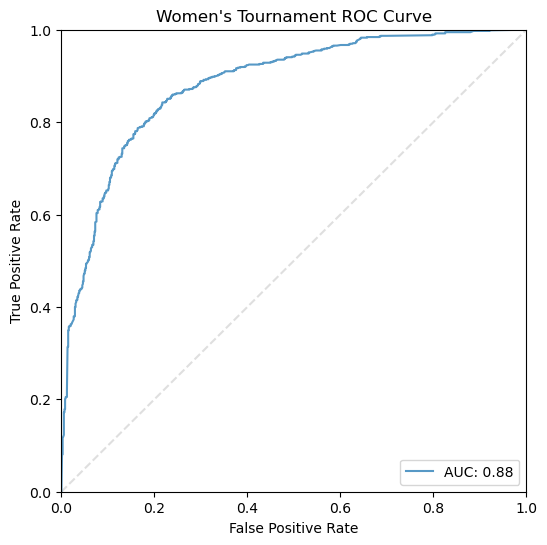

In [15]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(3.5, 3.5), dpi=400)
plt.figure(figsize=(6, 6), dpi=100)

plt.plot(fpr, tpr, label = f"AUC: {auc_value:.2f}", alpha=0.75)
plt.axline([0, 0], [1, 1], color='gray', linestyle='--', alpha=0.25)

plt.title("Women's Tournament ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right')

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)

plt.show()

In [16]:
from sklearn.metrics import log_loss

print('Out-of-sample log losses by season')
for season in sorted(df_test['Season'].unique()):
    print(f"{season}: {log_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

Out-of-sample log losses by season
2012: 0.3506
2013: 0.4888
2014: 0.4191
2015: 0.3412
2016: 0.5248
2017: 0.4424
2018: 0.4761
2019: 0.4184
2021: 0.4195
2022: 0.4768
2023: 0.5018
2024: 0.3864


In [17]:
print('Out-of-sample Brier scores by season')
for season in sorted(df_test['Season'].unique()):
    print(f"{season}: {brier_score_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

Out-of-sample Brier scores by season
2012: 0.1049
2013: 0.1576
2014: 0.1326
2015: 0.0993
2016: 0.1737
2017: 0.1379
2018: 0.1569
2019: 0.1316
2021: 0.1290
2022: 0.1561
2023: 0.1639
2024: 0.1170


In [ ]:
# df_test.loc[(df_test['Season'] == 2023) & (df_test['Team A'] == 'LSU'), 'Prediction'] = 0.9999
# df_test.loc[(df_test['Season'] == 2023) & (df_test['Team B'] == 'LSU'), 'Prediction'] = 0.0001

# print('Out-of-sample Brier scores by season')
# for season in sorted(df_test['Season'].unique()):
#     print(f"{season}: {brier_score_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

Out-of-sample Brier scores by season
2012: 0.1049
2013: 0.1576
2014: 0.1326
2015: 0.0993
2016: 0.1737
2017: 0.1379
2018: 0.1569
2019: 0.1316
2021: 0.1290
2022: 0.1561
2023: 0.1568
2024: 0.1170


In [ ]:
# df_test.loc[(df_test['Season'] == 2021) & (df_test['Team A'] == 'Stanford'), 'Prediction'] = 0.9999
# df_test.loc[(df_test['Season'] == 2021) & (df_test['Team B'] == 'Stanford'), 'Prediction'] = 0.0001

# print('Out-of-sample log losses by season')
# for season in sorted(df_test['Season'].unique()):
#     print(f"{season}: {log_loss(df_test.loc[df_test['Season'] == season, 'Result'], df_test.loc[df_test['Season'] == season, 'Prediction']):.4f}")

Out-of-sample log losses by season
2012: 0.3506
2013: 0.4888
2014: 0.4191
2015: 0.3412
2016: 0.5248
2017: 0.4424
2018: 0.4761
2019: 0.4184
2021: 0.4934
2022: 0.4768
2023: 0.4741
2024: 0.3864


In [35]:
def get_bin_sample_sizes(y_prob, n_bins):
    y_prob = pd.Series(y_prob)
    bins = pd.cut(
        y_prob,
        np.linspace(0.0, 1.0, n_bins + 1),
    )

    return np.array([y_prob.loc[(y_prob > bin.left) & (y_prob <= bin.right)].shape[0] for bin in sorted(bins.unique())])

bin_sample_sizes = get_bin_sample_sizes(np.hstack(df_test['Prediction']), 20)

bin_sample_sizes

array([135, 184, 109,  65,  73,  70,  54,  39,  36,  23,  36,  56,  68,
        80,  51, 108, 187, 138])

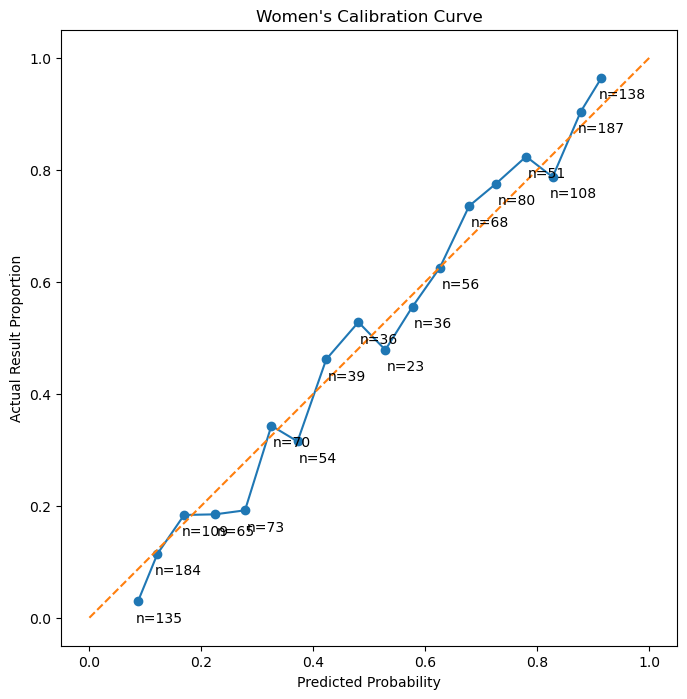

In [36]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    df_test['Result'], 
    df_test['Prediction'], 
    n_bins=20,
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(prob_pred, prob_true, marker='o')
ax.plot([0, 1], [0, 1], linestyle='dashed')

for i, (xi, yi, ni) in enumerate(zip(prob_pred, prob_true, bin_sample_sizes)):
    plt.annotate(f'n={ni}', (xi, yi), textcoords='offset points', xytext=(15, -15), ha='center')

ax.set_aspect('equal')

plt.title("Women's Calibration Curve")
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Result Proportion')

plt.show()

In [17]:
df_test['Prediction'].describe()

count    1512.000000
mean        0.499679
std         0.311473
min         0.080425
25%         0.172552
50%         0.491078
75%         0.826791
max         0.919596
Name: Prediction, dtype: float64

In [18]:
# convert results to 0/1 instead of -1/1 for this analysis
((df_test['Result'] + 1)/2 - df_test['Prediction']).abs().describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).round(4)

count    1512.0000
mean        0.2914
std         0.2313
min         0.0804
1%          0.0804
5%          0.0831
25%         0.1169
50%         0.1914
75%         0.3779
95%         0.8226
99%         0.8871
max         0.9196
dtype: float64

In [19]:
df_test.loc[((df_test['Result'] + 1)/2 - df_test['Prediction']).abs() > 0.90, :]

,Season,Result,Team A ID,Team A,Team B ID,Team B,Round,Location,Seed,Head to Head,Common Opps,Past Year Tournament Result,Past 4 Years Tournament Results,WIN%,ADJOE,ADJDE,ADJEM,BARTHAG,ADJ T.,WAB,Past Year Efficiency Margin,Past 4 Years Efficiency Margin,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo,Starters,Mu,OS Rating,Team Win%,Team EFG%,Opponent EFG%,Team TOR,Team ORBR,Team FTR,Opponent FTR,Team A ADJOE Team B ADJDE,Team B ADJOE Team A ADJDE,Team A Offense Team B Defense,Team B Offense Team A Defense,Team A Efficiency Margin,Team B Efficiency Margin,Prediction
554,2013,1,3208,Georgia,3390,Stanford,3,0,3,NaN,-0.879411,-4.0,-2.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.217909,-0.277231,-2.687332,-0.153412,-0.134997,0.018416,2.726064,-0.364275,-9.650903,-8.927956,-0.132942,-0.062626,0.059109,2.510934,3.038801,-0.528796,-0.681033,NaN,NaN,1.667536,1.820948,0.252515,0.405927,0.088697
557,2013,1,3257,Louisville,3124,Baylor,3,0,4,NaN,-1.203055,-5.0,-2.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.306015,-0.173513,-2.731550,-0.227979,-0.123222,0.104757,-2.557074,-0.463962,-16.826533,-16.640854,-0.219697,-0.058288,0.041062,4.017959,2.202958,-0.155007,6.236457,NaN,NaN,1.685546,1.913525,0.319770,0.547749,0.083104
614,2016,1,3449,Washington,3268,Maryland,2,-1,5,NaN,-1.371735,-4.0,-4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.161283,-0.231100,-1.167122,-0.180404,-0.114703,0.065701,-1.123638,-0.244271,-9.819209,-9.485734,-0.221591,-0.076114,0.013390,-3.144970,-6.329466,4.554378,-0.319592,NaN,NaN,1.774517,1.954921,0.249110,0.429513,0.084581
728,2023,1,3279,Mississippi,3390,Stanford,2,-1,7,NaN,-0.794867,-4.0,-5.00,-0.106549,-14.7,-0.7,-14.0,-0.0206,0.0,-6.5,-0.162460,-0.331071,-1.011216,-0.142098,-0.141242,0.000856,0.832615,-0.348505,-6.586332,-6.900011,-0.106549,-0.050256,0.000846,0.878654,-1.356834,-1.110117,6.583458,181.3,195.3,1.755246,1.897344,0.304226,0.446324,0.088697
806,2013,-1,3390,Stanford,3208,Georgia,3,0,-3,NaN,0.879411,4.0,2.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.217909,0.277231,2.687332,0.153412,0.134997,-0.018416,-2.726064,0.364275,9.650903,8.927956,0.132942,0.062626,-0.059109,-2.510934,-3.038801,0.528796,0.681033,NaN,NaN,1.820948,1.667536,0.405927,0.252515,0.910963
809,2013,-1,3124,Baylor,3257,Louisville,3,0,-4,NaN,1.203055,5.0,2.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.306015,0.173513,2.731550,0.227979,0.123222,-0.104757,2.557074,0.463962,16.826533,16.640854,0.219697,0.058288,-0.041062,-4.017959,-2.202958,0.155007,-6.236457,NaN,NaN,1.913525,1.685546,0.547749,0.319770,0.919596
866,2016,-1,3268,Maryland,3449,Washington,2,1,-5,NaN,1.371735,4.0,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.161283,0.231100,1.167122,0.180404,0.114703,-0.065701,1.123638,0.244271,9.819209,9.485734,0.221591,0.076114,-0.013390,3.144970,6.329466,-4.554378,0.319592,NaN,NaN,1.954921,1.774517,0.429513,0.249110,0.916673
878,2016,-1,3124,Baylor,3333,Oregon St,4,0,-1,NaN,NaN,2.0,3.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.083214,0.287099,0.293982,0.085613,0.076860,-0.008753,5.378361,0.197656,6.074458,5.445517,0.095588,0.015721,0.023297,-1.214675,3.347207,4.801951,-1.830351,NaN,NaN,1.795669,1.710056,0.439235,0.353622,0.901208
980,2023,-1,3390,Stanford,3279,Mississippi,2,1,-7,NaN,0.794867,4.0,5.00,0.106549,14.7,0.7,14.0,0.0206,0.0,6.5,0.162460,0.331071,1.011216,0.142098,0.141242,-0.000856,-0.832615,0.348505,6.586332,6.900011,0.106549,0.050256,-0.000846,-0.878654,1.356834,1.110117,-6.583458,195.3,181.3,1.897344,1.755246,0.446324,0.304226,0.910704


### Train Final Model

In [20]:
np.random.seed(22)

val_seasons = np.random.choice(df_train_val_iter['Season'].unique(), size=3, replace=False)

X_train = (
    df_mod
    .loc[~df_mod['Season'].isin(val_seasons), :]
    .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
)

X_val = (
    df_mod
    .loc[df_mod['Season'].isin(val_seasons), :]
    .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
)

y_train = (
    df_mod
    .loc[~df_mod['Season'].isin(val_seasons), 'Result']
)

y_val = (
    df_mod
    .loc[df_mod['Season'].isin(val_seasons), 'Result']
)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1134, 37), (378, 37), (1134,), (378,))

In [21]:
params = (
    {
        'random_state': 22,
        # 'metric': 'binary_logloss',
        'metric': 'rmse',  # brier score
        'verbosity': -1,
        'n_estimators': 500,
        'early_stopping_round': 25,
        'monotone_constraints': monotone_constraints,
    } |
    study.best_params
)

mod = LGBMClassifier(**params)

mod.fit(
    X_train, 
    y_train, 
    eval_set=(X_val, y_val),
)

LGBMClassifier(early_stopping_round=25, feature_fraction=0.6927277599076377,
               lambda_l1=9.058505139074182, lambda_l2=5.2722264970292905,
               max_depth=21, metric='rmse', min_child_samples=1,
               monotone_constraints=[0, 1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1,
                                     1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, -1,
                                     -1, 1, 0, ...],
               n_estimators=500, num_leaves=87, random_state=22, verbosity=-1)

In [22]:
mod.predict_proba(X_train)[:, 1]

array([0.7341659 , 0.94756924, 0.73209751, ..., 0.60271255, 0.08417503,
       0.15400495])

### Feature Insights

In [23]:
import shap

explainer = shap.Explainer(mod, feature_names=X_train.columns, seed=22)

shap_values = explainer(X_train)

shap_values.shape

(1134, 37)

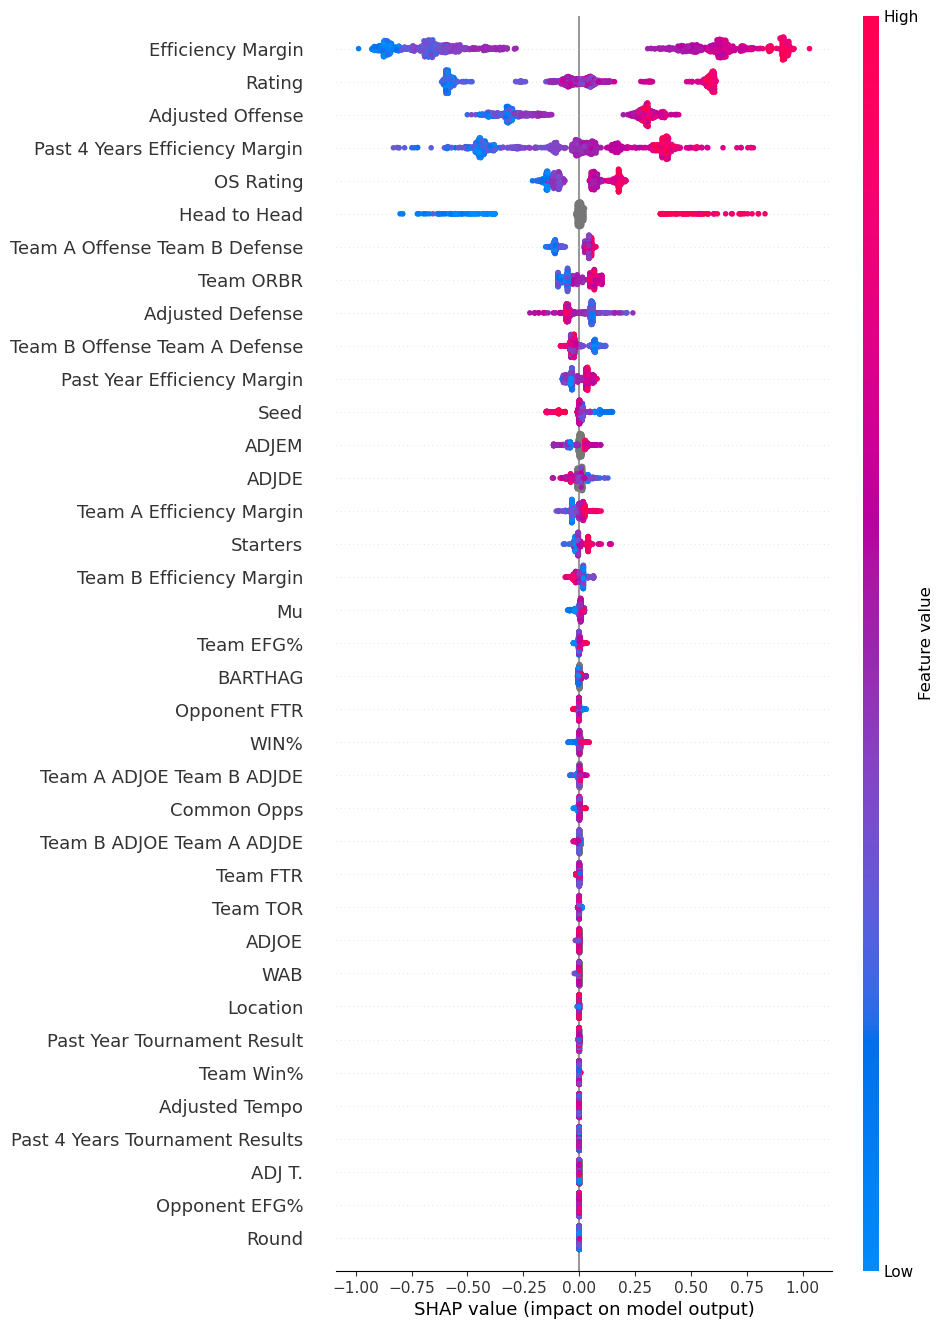

In [24]:
shap.plots.beeswarm(shap_values, max_display=None)

In [25]:
df_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': mod.feature_importances_,
}).sort_values(['Importance'], ascending=False, ignore_index=True)

df_feature_importance

,Feature,Importance
0,Head to Head,86
1,Efficiency Margin,69
2,Past 4 Years Efficiency Margin,67
3,Seed,41
4,Adjusted Offense,39
5,OS Rating,33
6,Rating,31
7,Adjusted Defense,27
8,Starters,26
9,Past Year Efficiency Margin,25


### Save

In [30]:
import pickle

with open('../data/models/womens/2025_03_07_model.pkl', 'wb') as f:
    pickle.dump(mod, f)

df_mod.to_parquet('../data/models/womens/2025_03_07_data.parquet')

'Done'

'Done'